In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.ReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.ReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.ReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.MaxPool2d(2),          # 32 → 16
    nn.ReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 16 → 8
    nn.ReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.ReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.ReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.ReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.MaxPool2d(2),          # 8 → 4
    nn.ReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 4 → 2
    nn.ReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model3_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model3_0)
describe(model3_0)

MACs: 7.77 MMac, Params: 56.06 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-4                    [1, 30, 32, 32]           --
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-7                    [1, 30, 32, 32]           --
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-10                   [1, 30, 3

Loading checkpoint from model_weights/model3_0.pt
Starting
Epoch 1/60: Train loss = 1.3555, Train accuracy = 0.5250, Test loss = 1.3184, Test accuracy = 0.5428
Epoch 2/60: Train loss = 1.0764, Train accuracy = 0.6226, Test loss = 1.0832, Test accuracy = 0.6197
Epoch 3/60: Train loss = 0.8721, Train accuracy = 0.6957, Test loss = 0.8726, Test accuracy = 0.6998
Epoch 4/60: Train loss = 0.8108, Train accuracy = 0.7148, Test loss = 0.8116, Test accuracy = 0.7143
Epoch 5/60: Train loss = 0.7407, Train accuracy = 0.7397, Test loss = 0.7602, Test accuracy = 0.7401
Epoch 6/60: Train loss = 0.7641, Train accuracy = 0.7360, Test loss = 0.7775, Test accuracy = 0.7389
Epoch 7/60: Train loss = 0.7302, Train accuracy = 0.7477, Test loss = 0.7732, Test accuracy = 0.7383
Epoch 8/60: Train loss = 0.6677, Train accuracy = 0.7673, Test loss = 0.6912, Test accuracy = 0.7579
Epoch 9/60: Train loss = 0.7130, Train accuracy = 0.7515, Test loss = 0.7649, Test accuracy = 0.7441
Epoch 10/60: Train loss = 0.6302

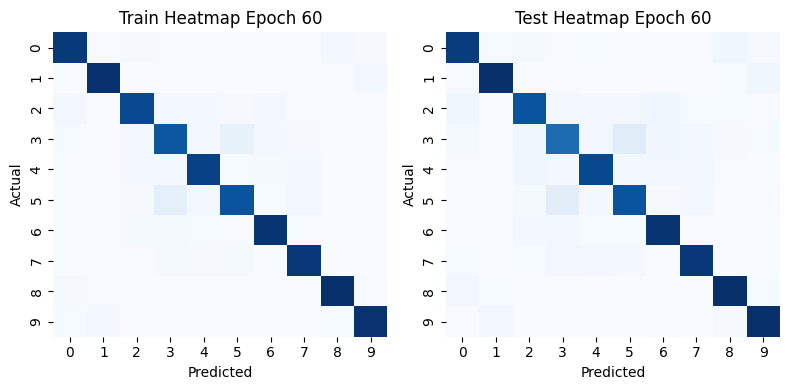

<Figure size 1200x600 with 0 Axes>

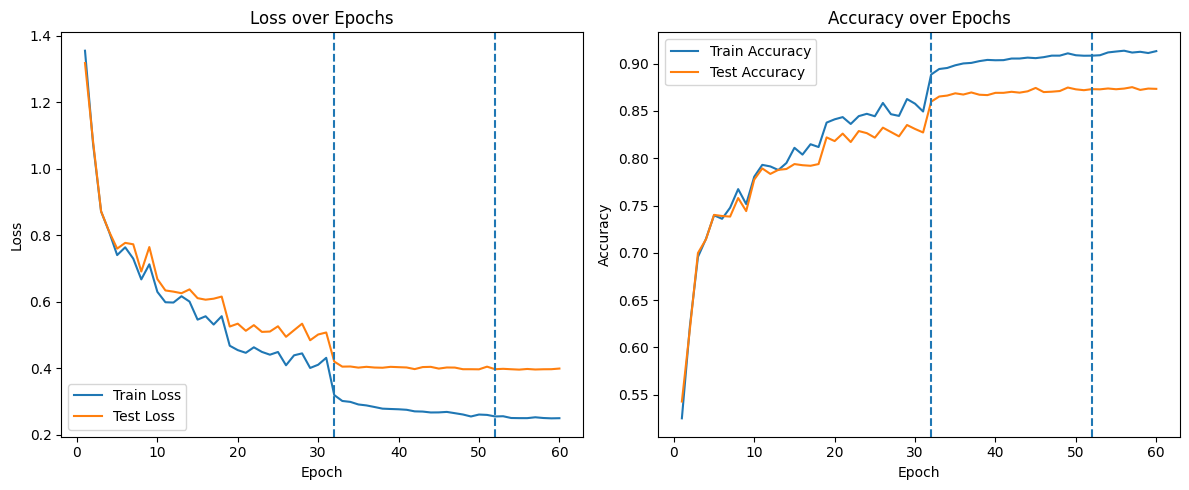

In [6]:
trainf32(model3_0,"model_weights/model3_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model3_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model3_1)
describe(model3_1)

MACs: 7.77 MMac, Params: 56.06 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-4                    [1, 30, 32, 32]           --
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-7                    [1, 30, 32, 32]           --
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-10                   [1, 30, 3

Loading checkpoint from model_weights/model3_1.pt
Starting
Epoch 1/60: Train loss = 1.2802, Train accuracy = 0.5597, Test loss = 1.2789, Test accuracy = 0.5744
Epoch 2/60: Train loss = 0.9297, Train accuracy = 0.6752, Test loss = 0.9382, Test accuracy = 0.6800
Epoch 3/60: Train loss = 0.8752, Train accuracy = 0.6949, Test loss = 0.8647, Test accuracy = 0.7068
Epoch 4/60: Train loss = 0.6999, Train accuracy = 0.7573, Test loss = 0.7070, Test accuracy = 0.7596
Epoch 5/60: Train loss = 0.7063, Train accuracy = 0.7533, Test loss = 0.7291, Test accuracy = 0.7505
Epoch 6/60: Train loss = 0.7462, Train accuracy = 0.7421, Test loss = 0.7668, Test accuracy = 0.7362
Epoch 7/60: Train loss = 0.5804, Train accuracy = 0.7992, Test loss = 0.6148, Test accuracy = 0.7901
Epoch 8/60: Train loss = 0.6007, Train accuracy = 0.7906, Test loss = 0.6400, Test accuracy = 0.7862
Epoch 9/60: Train loss = 0.5757, Train accuracy = 0.7992, Test loss = 0.6057, Test accuracy = 0.7945
Epoch 10/60: Train loss = 0.5783

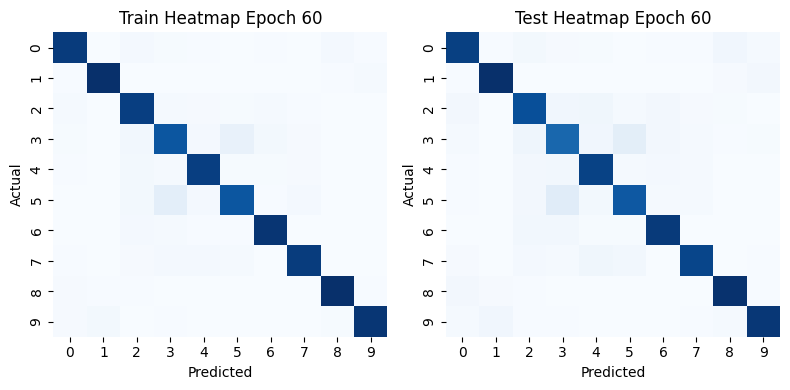

<Figure size 1200x600 with 0 Axes>

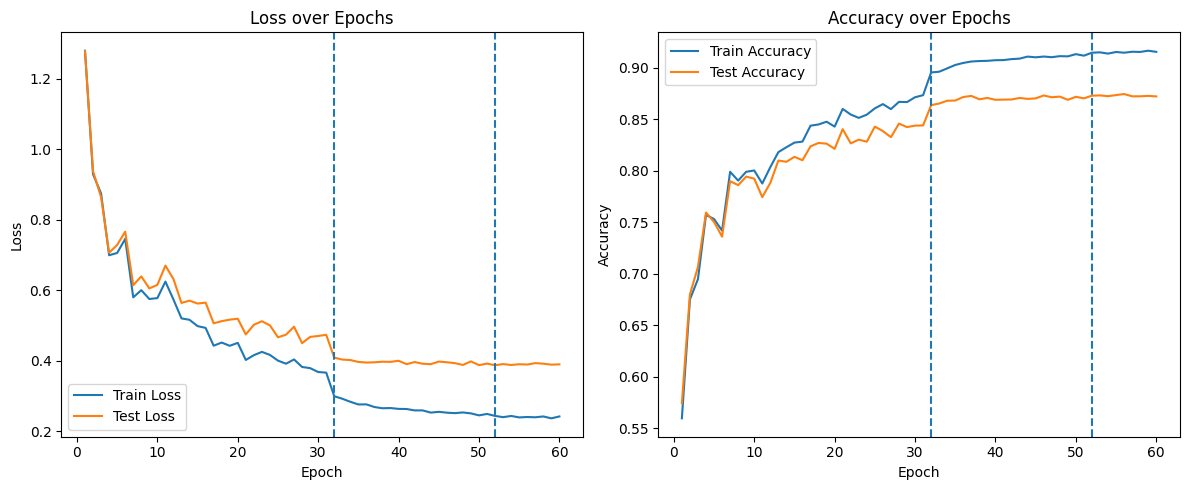

In [8]:
trainf32(model3_1,"model_weights/model3_1.pt",criterion,train_dataset,val_dataset, batch_size=64)